In [ ]:
# ====================================================================================
# Copyright (c) 2026 [Haitham Sobhy]

# Permission is hereby granted, free of charge, to academic and non-profit
# researchers to inspect, run, and evaluate this software solely for non-profit
# academic research and peer-review evaluation purposes.

# MANDATORY CITATION REQUIREMENT:
# Any academic or non-profit usage, evaluation, or reference to this software
# MUST cite the following work:
# "Shetti-AI: Precise prediction of protein sequence mutational landscapes to
# accelerate functional assays (Under Revision)"

# RESTRICTIONS & PERMISSION REQUIREMENTS:

# 1. NO COMMERCIAL OR R&D USE: Any use, modification, integration, or testing by
#    or on behalf of commercial entities, for-profit corporations, or corporate
#    Research & Development (R&D) departments is STRICTLY PROHIBITED.

# 2. PRIOR PERMISSION REQUIRED: No part of this codebase, scripts, or algorithms
#    may be copied, modified, redistributed, or incorporated into other projects
#    without explicit prior written permission from the copyright holder.

# 3. COMMERCIAL LICENSING: For commercial inquiries, corporate R&D licensing,
#    or permission requests, please contact: [ hsobhy at live dot com ]

# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR IMPLIED.
# ====================================================================================

In [ ]:
# Bayesian hybrid mutation


Enter motif: MREL
Enter physicochemical beta (default = 4.0): 4

BAYESIAN MUTATION ANALYSIS: MREL
Physicochemical beta = 4.0
 Position From To Mutant  SNP_Distance  Genetic_Weight Phys_Similarity Prior Likelihood Posterior
        3    E  D   MRDL             1             3.0          0.4536 7.32%     6.1379    17.29%
        4    L  I   MREI             1             3.0          0.5383 6.25%     8.6121    16.80%
        2    R  K   MKEL             1             3.0          0.4806 6.12%     6.8364    16.16%
        4    L  V   MREV             1             3.0          0.4436 6.25%     5.8979    11.50%
        1    M  L   LREL             1             3.0          0.2931 8.11%     3.2299    10.67%
        1    M  I   IREL             1             3.0          0.2862 8.11%     3.1419    10.38%
        1    M  V   VREL             1             3.0          0.2768 8.11%     3.0256     9.99%
        3    E  Q   MRQL             1             3.0          0.2782 7.32%     3.0434   

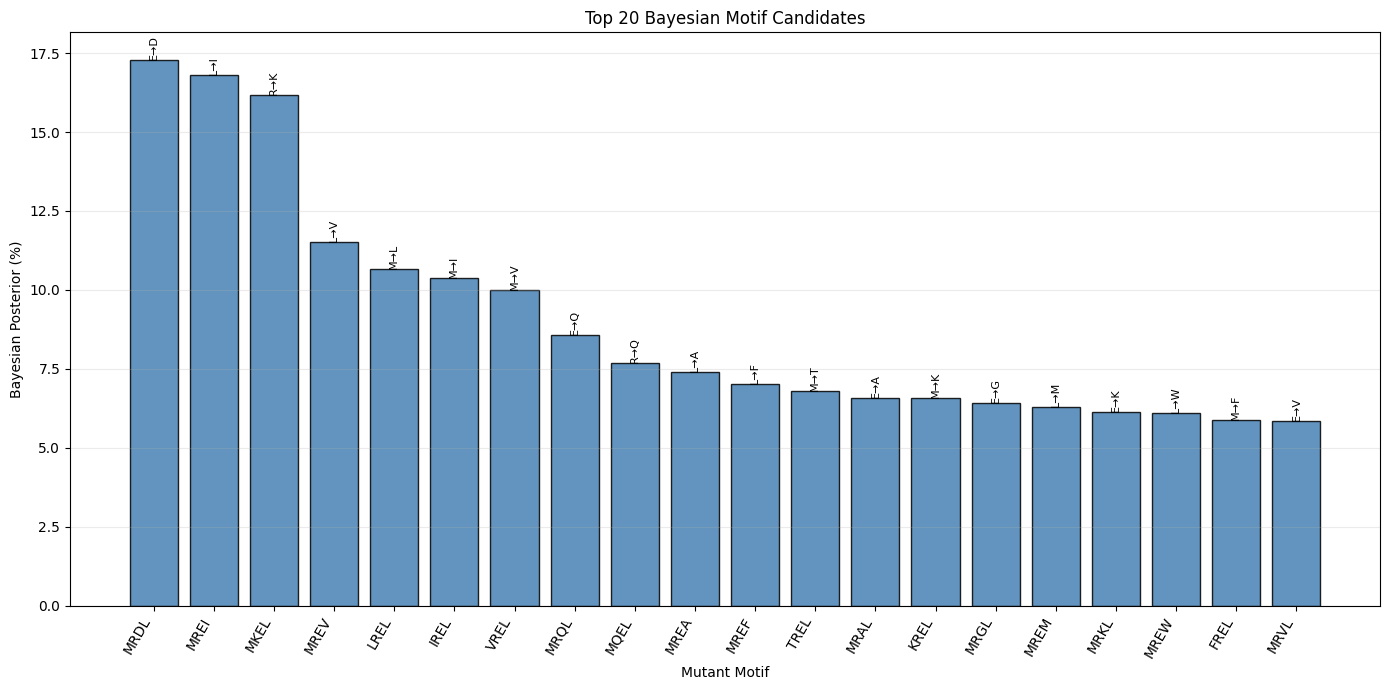

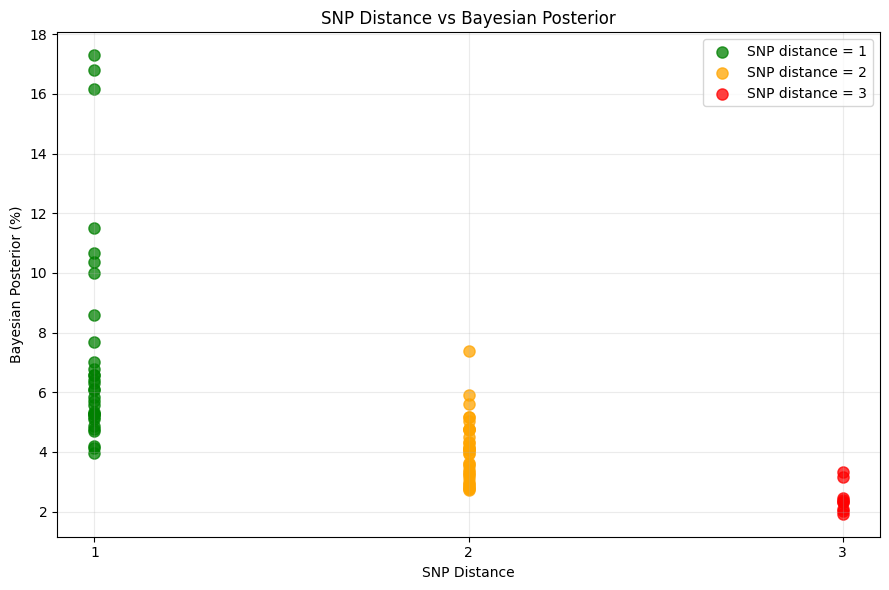

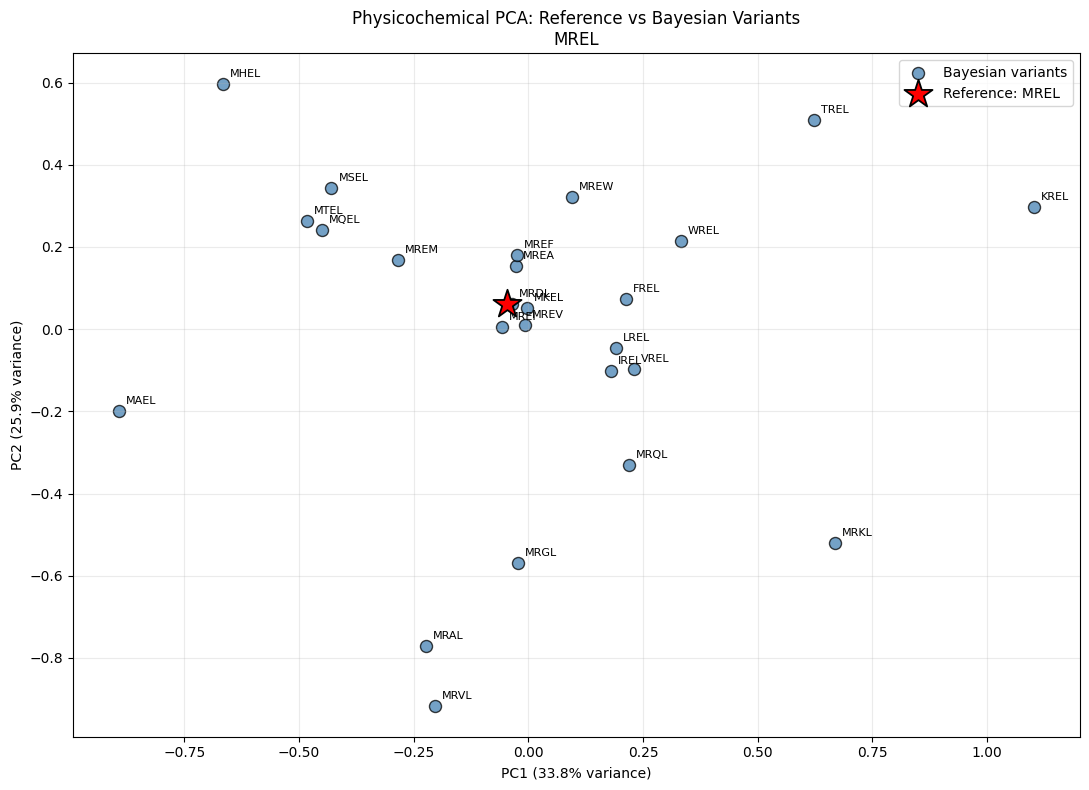

In [ ]:
"""
BAYESIAN AMINO-ACID MOTIF EVOLUTION MODEL
==========================================

Purpose
-------
Given an input peptide/protein motif, rank all possible single-residue
mutations using two sources of biological information:

    1. Genetic accessibility
       --------------------
       A user-configurable amino-acid substitution distance matrix
       derived from the genetic code.

    2. Physicochemical compatibility
       -------------------------------
       An 18-dimensional physicochemical representation of each
       amino acid.

The two sources are combined using a Bayesian formulation:

    Posterior(target | evidence)
        ∝
    Prior(target | genetic accessibility)
        ×
    Likelihood(physicochemical evidence | target)

This is NOT deep learning. It is an interpretable Bayesian/statistical
ranking model.

The same biological matrices can later be supplied to VAE/GAN/WGAN
models as biological features, constraints, priors, or post-generation
filters.
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


# ============================================================
# 1. AMINO-ACID DEFINITIONS
# ============================================================

AA_LIST = "ARNDCEQGHILKMFPSTWYV"

AA_IDX = {
    aa: i
    for i, aa in enumerate(AA_LIST)
}


# ============================================================
# 2. PHYSICOCHEMICAL DATA
# ============================================================
#
# 18-dimensional representation:
#
# 1  Charge
# 2  Hydropathy
# 3  Polarity
# 4  Volume
# 5  Flexibility
# 6  Aromaticity
# 7  Sulfur Content
# 8  Reactivity
# 9  Hydrogen Bonding
# 10 Alpha Helix Propensity
# 11 Beta Sheet Propensity
# 12 Turn Propensity
# 13 Disorder Propensity
# 14 General PTM
# 15 Phosphorylation
# 16 Acetylation
# 17 Metal Binding
# 18 Protein Interaction
#
# Values are represented on the normalized [-1, +1] scale
# according to the data supplied by the user.
#
# IMPORTANT:
# These values are treated as FEATURES, not probabilities.
# ============================================================

PHYSICAL_PROPS = {
    'A': [0,0.4,-0.42,-0.68,-0.21,-1,-1,-1,-0.33,0.65,0.12,-0.56,-0.75,-1,-1,-1,-1,-0.2],
    'R': [1,-1,0.75,0.43,0.32,-1,-1,0,0.85,0.1,-0.35,-0.22,0,0,-1,1,-1,1],
    'N': [0,-0.78,0.9,-0.34,0.15,-1,-1,0,0.85,-0.45,-0.35,0.48,0.3,0,-1,-1,-1,0.5],
    'D': [-1,-0.78,0.9,-0.37,0.42,-1,-1,0,0.85,0.12,-0.7,0.52,0.5,-1,-1,-1,1,0.5],
    'C': [0,0.51,-0.3,-0.41,-0.3,-1,1,1,-0.33,-0.3,0.5,0.18,-0.6,0,-1,-1,1,0],
    'E': [-1,-0.78,0.9,-0.05,0.28,-1,-1,0,0.85,0.8,-0.8,-0.4,0.4,-1,-1,-1,1,0.5],
    'Q': [0,-0.78,0.9,0,0.22,-1,-1,0,0.85,0.4,-0.1,-0.22,0.2,0,-1,-1,-1,0.5],
    'G': [0,-0.18,-0.05,-1,0.9,-1,-1,-1,-0.33,-0.8,-0.5,1,0.8,-1,-1,-1,-1,0],
    'H': [0,-0.71,0.6,0.19,-0.5,1,-1,0,0.85,0.3,-0.2,-0.22,-0.1,0,0,-1,1,0.5],
    'I': [0,1,-1,0.34,0.1,-1,-1,-1,-0.33,0.1,0.8,-0.8,-0.8,-1,-1,-1,-1,0],
    'L': [0,0.84,-1,0.34,-0.25,-1,-1,-1,-0.33,0.7,0.4,-0.56,-0.7,-1,-1,-1,-1,0],
    'K': [1,-0.87,0.75,0.36,0.18,-1,-1,0,0.85,0.4,-0.2,-0.1,0,1,-1,1,-1,1],
    'M': [0,0.42,-0.6,0.28,-0.6,-1,1,-1,-0.33,0.4,0.9,-0.5,-0.6,-1,-1,-1,0,0],
    'F': [0,0.62,-0.8,0.58,-0.55,1,-1,-1,-0.33,0.2,0.5,-0.5,-0.7,-1,-1,-1,-1,0],
    'P': [0,-0.36,-0.3,-0.35,-1,-1,-1,-1,-0.33,-1,-0.8,1,0.6,0,-1,-1,-1,-0.2],
    'S': [0,-0.2,0.9,-0.66,0.42,-1,-1,0,0.85,-0.3,-0.4,0.7,0.5,1,1,-1,-1,0.5],
    'T': [0,-0.16,0.75,-0.31,0.05,-1,-1,0,0.85,-0.2,0.3,0.4,0.2,1,1,-1,-1,0.5],
    'W': [0,-0.09,-0.5,1,-0.55,1,-1,-1,0.3,0.3,0.3,-0.22,-0.8,-1,-1,-1,-1,0],
    'Y': [0,-0.51,0.3,0.65,-0.05,1,-1,0,0.3,-0.2,0.5,0.18,-0.1,0,1,-1,-1,0],
    'V': [0,0.93,-1,0.02,-0.1,-1,-1,-1,-0.33,0.3,0.9,-0.7,-0.8,0,-1,-1,-1,0]
}

PHYS_DIM = 18


# Convert to NumPy arrays and validate dimensions
PHYSICAL_PROPS = {
    aa: np.asarray(values, dtype=float)
    for aa, values in PHYSICAL_PROPS.items()
}

for aa, vector in PHYSICAL_PROPS.items():

    if len(vector) != PHYS_DIM:
        raise ValueError(
            f"{aa} has {len(vector)} physicochemical features; "
            f"expected {PHYS_DIM}."
        )


# ============================================================
# 3. USER-CONFIGURABLE GENETIC DISTANCE MATRIX
# ============================================================
#
# D[i,j] represents the currently selected genetic/codon-derived
# distance between amino acids i and j.
#
# IMPORTANT:
# This matrix is deliberately external to the model.
#
# Users can replace it with:
#   - codon-aware distance
#   - transition/transversion weighted distance
#   - taxon-specific accessibility
#   - codon-usage-weighted distance
#   - another experimentally justified matrix
#
# The Bayesian engine does not need to be rewritten.
# ============================================================

SNP_DISTANCE = np.array([
    [0,1,2,1,2,1,2,1,2,2,2,2,3,2,1,1,1,2,2,1],
    [1,0,2,2,1,2,1,1,1,2,1,1,2,2,1,1,1,1,2,2],
    [2,2,0,1,2,2,2,2,1,1,2,1,2,2,2,1,1,3,1,2],
    [1,2,1,0,2,1,2,1,1,2,2,2,3,2,2,2,2,3,1,1],
    [2,1,2,2,0,3,2,1,2,2,2,3,3,1,2,1,2,1,1,2],
    [1,2,2,1,3,0,1,1,2,2,2,1,2,3,2,2,2,3,2,1],
    [2,1,2,2,2,1,0,2,1,1,2,1,2,3,1,2,2,2,2,2],
    [1,1,2,1,1,1,2,0,2,2,2,2,3,2,2,1,2,1,2,1],
    [2,1,1,1,2,2,1,2,0,2,1,2,2,2,1,2,2,3,1,2],
    [2,2,1,2,2,2,2,2,2,0,1,1,1,1,2,1,1,2,2,1],
    [2,1,2,2,2,2,1,2,1,1,0,2,1,1,1,1,2,1,2,1],
    [2,1,1,2,3,1,1,2,2,1,2,0,1,3,2,2,1,3,2,2],
    [3,2,2,3,3,2,2,3,2,1,1,1,0,2,3,2,1,2,3,1],
    [2,2,2,2,1,3,3,2,2,1,1,3,2,0,2,1,2,2,1,1],
    [1,1,2,2,2,2,1,2,1,2,1,2,3,2,0,1,1,2,2,2],
    [1,1,1,2,1,2,2,1,2,1,1,2,2,1,1,0,1,1,1,2],
    [1,1,1,2,2,2,2,2,2,1,2,1,1,2,1,1,0,2,2,1],
    [2,1,3,3,1,3,2,1,3,2,1,3,2,2,2,1,2,0,3,2],
    [2,2,1,1,1,2,2,2,1,2,2,2,3,1,2,1,2,3,0,2],
    [1,2,2,1,2,1,2,1,2,1,1,2,1,1,2,2,1,2,2,0]
], dtype=float)


if SNP_DISTANCE.shape != (20, 20):
    raise ValueError(
        "SNP_DISTANCE must be a 20 × 20 matrix."
    )


# ============================================================
# 4. GENETIC ACCESSIBILITY WEIGHT
# ============================================================
#
# Your original biological weighting:
#
# distance = 1 -> weight 3
# distance = 2 -> weight 2
# distance = 3 -> weight 1
#
# distance = 0 means the original amino acid and is excluded
# from the mutation candidate set.
# ============================================================

def genetic_weight(distance):

    if distance == 1:
        return 3.0

    elif distance == 2:
        return 2.0

    elif distance == 3:
        return 1.0

    return 0.0


# ============================================================
# 5. GENETIC PRIOR
# ============================================================
#
# We convert genetic accessibility into:
#
#       P(target | source, genetic evidence)
#
# using normalized weights.
#
# IMPORTANT:
# This is the Bayesian PRIOR for the target residue.
#
# We are NOT calling this probability a mutation frequency.
# It represents the prior preference induced by the supplied
# genetic-accessibility model.
# ============================================================

def genetic_prior(source_aa):

    source_idx = AA_IDX[source_aa]

    distances = SNP_DISTANCE[source_idx]

    weights = np.array([
        genetic_weight(d)
        for d in distances
    ])

    # Never allow the original residue to be a mutation candidate.
    weights[source_idx] = 0.0

    total = weights.sum()

    if total <= 0:
        raise ValueError(
            f"No valid mutation candidates for amino acid {source_aa}."
        )

    prior = weights / total

    return prior


# ============================================================
# 6. PHYSICOCHEMICAL DISTANCE
# ============================================================
#
# Euclidean distance in the 18-dimensional physicochemical space.
#
# Because all features are represented on approximately the same
# [-1,+1] scale, no additional standardization is required here.
#
# However, the function is isolated so that a future version can
# introduce feature-specific weights.
# ============================================================

def physical_distance(aa1, aa2):

    v1 = PHYSICAL_PROPS[aa1]
    v2 = PHYSICAL_PROPS[aa2]

    return np.linalg.norm(v1 - v2)


# ============================================================
# 7. PHYSICOCHEMICAL SIMILARITY
# ============================================================
#
# Converts distance into a positive compatibility score:
#
#       similarity = 1 / (1 + distance)
#
# Larger similarity = more physicochemically compatible.
# ============================================================

def physical_similarity(aa1, aa2):

    distance = physical_distance(
        aa1,
        aa2
    )

    return 1.0 / (1.0 + distance)


# ============================================================
# 8. BAYESIAN LIKELIHOOD
# ============================================================
#
# Similarity itself is not automatically a likelihood.
#
# We therefore transform similarity into a positive likelihood
# using an exponential model:
#
#       L_j = exp(beta * similarity_j)
#
# beta controls how strongly physicochemical compatibility
# influences the posterior.
#
# Larger beta:
#       stronger physicochemical selection
#
# Smaller beta:
#       weaker physicochemical selection
#
# This is a tunable model parameter rather than an arbitrary
# "probability."
# ============================================================

def physical_likelihood(
    source_aa,
    target_aa,
    beta=4.0
):

    similarity = physical_similarity(
        source_aa,
        target_aa
    )

    return np.exp(
        beta * similarity
    )


# ============================================================
# 9. BAYESIAN POSTERIOR
# ============================================================
#
# Bayes:
#
#   P(target | evidence)
#       =
#   P(evidence | target) P(target)
#   --------------------------------
#          P(evidence)
#
# Since the denominator is common to all candidates, we calculate:
#
#   posterior_raw =
#       genetic_prior × physical_likelihood
#
# and normalize across candidate residues.
#
# This is the central Bayesian calculation.
# ============================================================

def bayesian_residue_posterior(
    source_aa,
    beta=4.0
):

    prior = genetic_prior(
        source_aa
    )

    likelihood = np.zeros(20)

    for target_aa in AA_LIST:

        target_idx = AA_IDX[target_aa]

        # Original residue is not considered a mutation.
        if target_aa == source_aa:
            likelihood[target_idx] = 0.0
            continue

        likelihood[target_idx] = physical_likelihood(
            source_aa,
            target_aa,
            beta=beta
        )

    # Bayesian numerator:
    # prior × likelihood
    posterior_raw = (
        prior *
        likelihood
    )

    # Normalize to obtain posterior probability.
    total = posterior_raw.sum()

    if total <= 0:
        raise ValueError(
            "Posterior normalization failed."
        )

    posterior = (
        posterior_raw /
        total
    )

    return prior, likelihood, posterior


# ============================================================
# 10. ANALYZE ONE RESIDUE
# ============================================================

def analyze_residue(
    source_aa,
    beta=4.0
):

    prior, likelihood, posterior = \
        bayesian_residue_posterior(
            source_aa,
            beta=beta
        )

    rows = []

    source_idx = AA_IDX[source_aa]

    for target_aa in AA_LIST:

        target_idx = AA_IDX[target_aa]

        if target_aa == source_aa:
            continue

        rows.append({

            "Source": source_aa,

            "Target": target_aa,

            "SNP_Distance":
                int(
                    SNP_DISTANCE[
                        source_idx,
                        target_idx
                    ]
                ),

            "Genetic_Weight":
                genetic_weight(
                    SNP_DISTANCE[
                        source_idx,
                        target_idx
                    ]
                ),

            "Prior":
                prior[target_idx],

            "Phys_Distance":
                physical_distance(
                    source_aa,
                    target_aa
                ),

            "Phys_Similarity":
                physical_similarity(
                    source_aa,
                    target_aa
                ),

            "Likelihood":
                likelihood[target_idx],

            "Posterior":
                posterior[target_idx]
        })

    df = pd.DataFrame(rows)

    return df.sort_values(
        "Posterior",
        ascending=False
    ).reset_index(drop=True)


# ============================================================
# 11. MOTIF-LEVEL MUTATION GENERATION
# ============================================================
#
# Every position in the motif is analyzed independently.
#
# Example:
#
#       WWT
#
# position 1:
#       W -> 19 possible residues
#
# position 2:
#       W -> 19 possible residues
#
# position 3:
#       T -> 19 possible residues
#
# The result therefore contains all possible single-residue
# substitutions.
# ============================================================

def analyze_motif(
    motif,
    beta=4.0
):

    motif = motif.upper().strip()

    results = []

    for position, source_aa in enumerate(motif):

        if source_aa not in AA_IDX:
            raise ValueError(
                f"Invalid amino acid '{source_aa}' "
                f"at position {position + 1}."
            )

        residue_df = analyze_residue(
            source_aa,
            beta=beta
        )

        for _, row in residue_df.iterrows():

            target_aa = row["Target"]

            mutated = list(motif)

            mutated[position] = target_aa

            mutated = "".join(
                mutated
            )

            results.append({

                "Original":
                    motif,

                "Position":
                    position + 1,

                "From":
                    source_aa,

                "To":
                    target_aa,

                "Mutant":
                    mutated,

                "SNP_Distance":
                    int(row["SNP_Distance"]),

                "Genetic_Weight":
                    row["Genetic_Weight"],

                "Prior":
                    row["Prior"],

                "Phys_Distance":
                    row["Phys_Distance"],

                "Phys_Similarity":
                    row["Phys_Similarity"],

                "Likelihood":
                    row["Likelihood"],

                "Posterior":
                    row["Posterior"]
            })

    df = pd.DataFrame(results)

    return df.sort_values(
        "Posterior",
        ascending=False
    ).reset_index(drop=True)


# ============================================================
# 12. DISPLAY RESULTS
# ============================================================

def print_results(
    motif,
    beta=4.0,
    top_n=25
):

    df = analyze_motif(
        motif,
        beta=beta
    )

    print("\n" + "=" * 100)

    print(
        f"BAYESIAN MUTATION ANALYSIS: {motif}"
    )

    print(
        f"Physicochemical beta = {beta}"
    )

    print("=" * 100)

    display_df = df.head(top_n).copy()

    display_df["Prior"] *= 100
    display_df["Posterior"] *= 100

    print(
        display_df[
            [
                "Position",
                "From",
                "To",
                "Mutant",
                "SNP_Distance",
                "Genetic_Weight",
                "Phys_Similarity",
                "Prior",
                "Likelihood",
                "Posterior"
            ]
        ].to_string(
            index=False,
            formatters={
                "Phys_Similarity":
                    "{:.4f}".format,

                "Prior":
                    "{:.2f}%".format,

                "Likelihood":
                    "{:.4f}".format,

                "Posterior":
                    "{:.2f}%".format
            }
        )
    )

    print("=" * 100)

    return df


# ============================================================
# 13. MOTIF → 18D REPRESENTATION
# ============================================================
#
# Convert an entire motif into one 18-dimensional
# physicochemical representation.
#
# Every residue contributes its 18D vector and the vectors
# are averaged across the motif.
#
# This representation is used ONLY for the PCA visualization.
#
# It does NOT change the Bayesian equations.
# ============================================================

def motif_to_18d(motif):

    motif = motif.upper().strip()

    if len(motif) == 0:
        raise ValueError(
            "Motif cannot be empty."
        )

    for aa in motif:

        if aa not in AA_IDX:
            raise ValueError(
                f"Invalid amino acid '{aa}' in motif."
            )

    vectors = np.array([
        PHYSICAL_PROPS[aa]
        for aa in motif
    ])

    return vectors.mean(
        axis=0
    )


# ============================================================
# 14. PLOT TOP BAYESIAN CANDIDATES
# ============================================================
#
# This is the main Bayesian ranking figure.
#
# X-axis:
#       Actual mutant motif sequence.
#
# Y-axis:
#       Bayesian posterior probability.
#
# The plot therefore directly shows which complete motif
# variants are ranked highest by the Bayesian model.
#
# The mutation itself is displayed above each bar as:
#
#       From → To
#
# Example:
#
#       E → D
#
# ============================================================

def plot_top_bayesian_candidates(
    df,
    top_n=20
):

    plot_df = df.head(
        top_n
    ).copy()

    labels = plot_df[
        "Mutant"
    ].astype(str).tolist()

    posterior = (
        plot_df["Posterior"].values
        * 100
    )

    mutation_labels = [
        f"{row['From']}→{row['To']}"
        for _, row in plot_df.iterrows()
    ]

    plt.figure(
        figsize=(14, 7)
    )

    bars = plt.bar(
        range(len(plot_df)),
        posterior,
        color="steelblue",
        edgecolor="black",
        alpha=0.85
    )

    plt.xticks(
        range(len(plot_df)),
        labels,
        rotation=60,
        ha="right"
    )

    plt.ylabel(
        "Bayesian Posterior (%)"
    )

    plt.xlabel(
        "Mutant Motif"
    )

    plt.title(
        f"Top {top_n} Bayesian Motif Candidates"
    )

    # Display the actual residue substitution above each bar.
    for i, (bar, mutation) in enumerate(
        zip(bars, mutation_labels)
    ):

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            mutation,
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90
        )

    plt.grid(
        axis="y",
        alpha=0.25
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 15. PLOT SNP DISTANCE VS BAYESIAN POSTERIOR
# ============================================================
#
# This plot examines whether genetic accessibility is reflected
# in the final Bayesian posterior.
#
# Your genetic model defines:
#
#       SNP distance 1 → weight 3
#       SNP distance 2 → weight 2
#       SNP distance 3 → weight 1
#
# Therefore, smaller SNP distance has stronger genetic preference.
#
# The posterior also depends on physicochemical likelihood, so
# the points do not have to follow a perfect relationship.
#
# This figure therefore shows whether genetically more accessible
# substitutions tend to receive higher Bayesian posterior values.
# ============================================================

def plot_snp_distance_vs_posterior(
    df
):

    plt.figure(
        figsize=(9, 6)
    )

    colors = {
        1: "green",
        2: "orange",
        3: "red"
    }

    for distance in sorted(
        df["SNP_Distance"].unique()
    ):

        subset = df[
            df["SNP_Distance"] == distance
        ]

        plt.scatter(
            subset["SNP_Distance"],
            subset["Posterior"] * 100,
            s=65,
            alpha=0.75,
            color=colors.get(
                int(distance),
                "steelblue"
            ),
            label=f"SNP distance = {int(distance)}"
        )

    plt.xlabel(
        "SNP Distance"
    )

    plt.ylabel(
        "Bayesian Posterior (%)"
    )

    plt.title(
        "SNP Distance vs Bayesian Posterior"
    )

    plt.xticks(
        [1, 2, 3]
    )

    plt.grid(
        alpha=0.25
    )

    plt.legend()

    plt.tight_layout()

    plt.show()


# ============================================================
# 16. PCA: REFERENCE MOTIF + BAYESIAN VARIANTS
# ============================================================
#
# PCA visualizes the 18-dimensional physicochemical space.
#
# The reference motif is represented by:
#
#       ★
#
# The Bayesian mutant variants are represented by:
#
#       ●
#
# The reference is calculated using the SAME whole-motif
# representation as every mutant.
#
# Therefore:
#
#       reference motif → average 18D vector
#       mutant motif    → average 18D vector
#
# This allows the reference and variants to be compared
# consistently in the same physicochemical space.
#
# IMPORTANT:
# PCA is visualization only.
# It does NOT modify the Bayesian prior, likelihood,
# or posterior equations.
# ============================================================

def plot_bayesian_pca(
    motif,
    df,
    top_n=25
):

    motif = motif.upper().strip()

    plot_df = df.head(
        top_n
    ).copy()

    mutant_motifs = plot_df[
        "Mutant"
    ].tolist()

    # --------------------------------------------------------
    # Reference motif representation
    # --------------------------------------------------------

    reference_vector = motif_to_18d(
        motif
    )

    # --------------------------------------------------------
    # Mutant motif representations
    # --------------------------------------------------------

    mutant_vectors = np.array([
        motif_to_18d(mutant)
        for mutant in mutant_motifs
    ])

    # --------------------------------------------------------
    # Combine reference and mutant representations
    # --------------------------------------------------------

    all_vectors = np.vstack([
        reference_vector,
        mutant_vectors
    ])

    # --------------------------------------------------------
    # PCA
    # --------------------------------------------------------

    pca = PCA(
        n_components=2
    )

    coordinates = pca.fit_transform(
        all_vectors
    )

    # --------------------------------------------------------
    # Plot Bayesian variants
    # --------------------------------------------------------

    plt.figure(
        figsize=(11, 8)
    )

    plt.scatter(
        coordinates[1:, 0],
        coordinates[1:, 1],
        s=75,
        color="steelblue",
        alpha=0.75,
        edgecolor="black",
        label="Bayesian variants"
    )

    # --------------------------------------------------------
    # Plot reference motif as STAR
    # --------------------------------------------------------

    plt.scatter(
        coordinates[0, 0],
        coordinates[0, 1],
        marker="*",
        s=450,
        color="red",
        edgecolor="black",
        linewidth=1.3,
        label=f"Reference: {motif}",
        zorder=10
    )

    # --------------------------------------------------------
    # Label mutant motifs
    # --------------------------------------------------------

    for i, mutant in enumerate(
        mutant_motifs,
        start=1
    ):

        plt.annotate(
            mutant,
            (
                coordinates[i, 0],
                coordinates[i, 1]
            ),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=8
        )

    # --------------------------------------------------------
    # Axis labels
    # --------------------------------------------------------

    pc1 = (
        pca.explained_variance_ratio_[0]
        * 100
    )

    pc2 = (
        pca.explained_variance_ratio_[1]
        * 100
    )

    plt.xlabel(
        f"PC1 ({pc1:.1f}% variance)"
    )

    plt.ylabel(
        f"PC2 ({pc2:.1f}% variance)"
    )

    plt.title(
        f"Physicochemical PCA: Reference vs Bayesian Variants\n"
        f"{motif}"
    )

    plt.legend()

    plt.grid(
        alpha=0.25
    )

    plt.tight_layout()

    plt.show()


# ============================================================
# 17. RUN ALL ANALYSIS AND FIGURES
# ============================================================
#
# The motif is entered by the user.
#
# The Bayesian analysis is performed once.
#
# The same resulting dataframe is then supplied to the
# plotting functions.
#
# No motif such as WWT is hard-coded.
# ============================================================

if __name__ == "__main__":

    motif = input(
        "\nEnter motif: "
    ).upper().strip()

    try:

        beta = float(
            input(
                "Enter physicochemical beta "
                "(default = 4.0): "
            )
        )

    except ValueError:

        beta = 4.0

    # --------------------------------------------------------
    # Bayesian analysis
    # --------------------------------------------------------

    df = print_results(
        motif,
        beta=beta,
        top_n=25
    )

    # --------------------------------------------------------
    # Figure 1:
    # Top Bayesian candidates
    # --------------------------------------------------------

    plot_top_bayesian_candidates(
        df,
        top_n=20
    )

    # --------------------------------------------------------
    # Figure 2:
    # SNP distance vs Bayesian posterior
    # --------------------------------------------------------

    plot_snp_distance_vs_posterior(
        df
    )

    # --------------------------------------------------------
    # Figure 3:
    # PCA of reference motif and Bayesian variants
    # --------------------------------------------------------

    plot_bayesian_pca(
        motif,
        df,
        top_n=25
    )


In [ ]:
'''
beta = 4.0 is the strength of the physicochemical likelihood in your Bayesian model.

the model gives more preference to mutations that are physicochemically similar to the original amino acid.

Higher beta → physicochemical similarity has a stronger effect.
Lower beta → physicochemical similarity has a weaker effect.
beta = 0 → the physicochemical likelihood becomes the same for every candidate, so the Bayesian ranking is effectively driven by the genetic prior.

'''